# Gaussian distribution & random data generation
A short, visual guide — exactly what you need for the **Gaussian-noise augmentation** in your thesis (and for understanding what `rng.normal(...)` actually does).

You'll see:

1. What a Gaussian (normal) distribution looks like
2. Generating random samples with numpy
3. What mean (μ) and standard deviation (σ) control
4. Variance vs. standard deviation
5. The 68-95-99.7 rule
6. Other useful random generators (uniform, integers, choice)
7. **Gaussian noise as a thesis augmentation** — the actual use case
8. Reproducibility with seeds

Run each cell with **Shift + Enter**. Change numbers, re-run, watch what changes. That's how intuition for distributions sticks.


## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt


## 1. What does a Gaussian look like?

The Gaussian (normal) distribution is the **bell curve**. Its shape is completely fixed by two numbers:

- **μ** (mu) — the **mean**: where the centre of the bell sits.
- **σ** (sigma) — the **standard deviation**: how wide the bell is.

The formula is

$$ p(x) = \frac{1}{\sigma \sqrt{2\pi}} \, e^{-\frac{1}{2} \left( \frac{x - \mu}{\sigma} \right)^2} $$

You don't need to memorise it. Just remember: **plug in μ and σ, get a bell.**


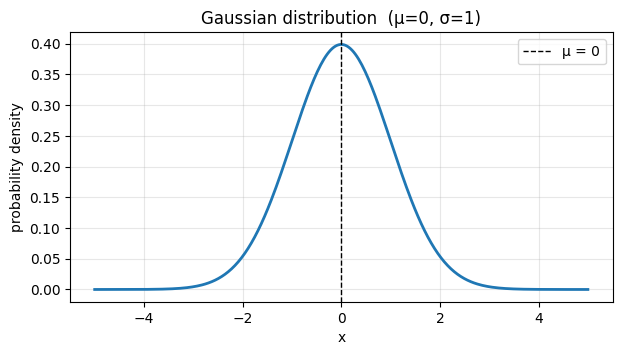

In [2]:
# Draw the bell curve for mu=0, sigma=1 (the "standard normal")
def gauss_pdf(x, mu, sigma):
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

mu, sigma = 0, 1
x = np.linspace(-5, 5, 300)

plt.figure(figsize=(7, 3.5))
plt.plot(x, gauss_pdf(x, mu, sigma), color="C0", linewidth=2)
plt.axvline(mu, color="black", linestyle="--", linewidth=1, label=f"μ = {mu}")
plt.title(f"Gaussian distribution  (μ={mu}, σ={sigma})")
plt.xlabel("x"); plt.ylabel("probability density")
plt.legend(); plt.grid(alpha=0.3)
plt.show()


## 2. Generating random samples
In numpy, you don't compute that ugly formula yourself — you ask numpy to **draw samples** from the distribution.

`rng.normal(mean, std, size)` gives you `size` independent random numbers from a bell curve with that mean and that std.


In [3]:
rng = np.random.default_rng(seed=42)

# 8 incomes, mean 40,000, typical variation 15,000
samples = rng.normal(40000, 15000, size=8)
np.round(samples)


array([44571., 24400., 51257., 54108., 10734., 20467., 41918., 35256.])

Sample mean: -0.02
Sample std : 0.999


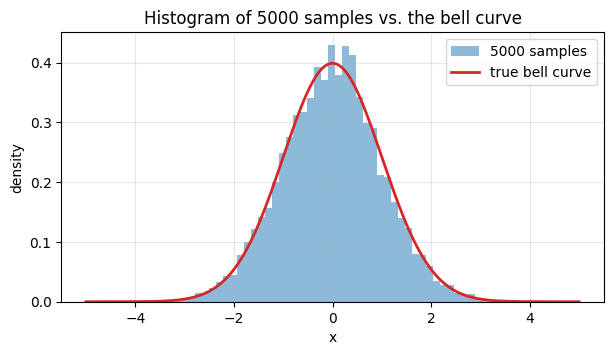

In [4]:
# Let's draw 5000 samples and look at their histogram
big_sample = rng.normal(loc=0, scale=1, size=5000)
print("Sample mean:", big_sample.mean().round(3))
print("Sample std :", big_sample.std().round(3))

plt.figure(figsize=(7, 3.5))
plt.hist(big_sample, bins=50, density=True, alpha=0.5, color="C0", label="5000 samples")
plt.plot(x, gauss_pdf(x, 0, 1), color="C3", linewidth=2, label="true bell curve")
plt.title("Histogram of 5000 samples vs. the bell curve")
plt.xlabel("x"); plt.ylabel("density")
plt.legend(); plt.grid(alpha=0.3)
plt.show()


**Notice:** the histogram of the samples matches the theoretical bell curve — that's exactly what „samples from a Gaussian" means.

## 3. What μ and σ actually control

- **μ shifts the bell left or right** — different centres.
- **σ stretches the bell wider or narrower** — different widths.


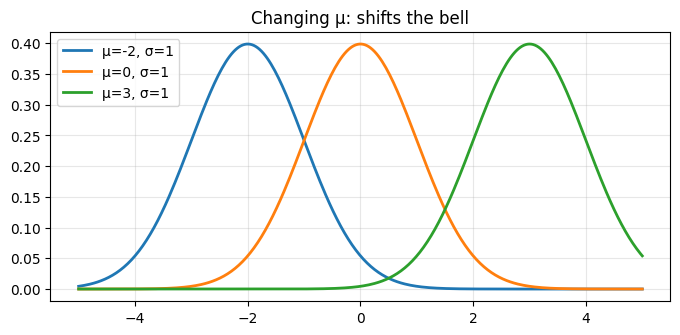

In [5]:
# Three Gaussians with the SAME width but different means
plt.figure(figsize=(8, 3.5))
for mu, color in zip([-2, 0, 3], ["C0", "C1", "C2"]):
    plt.plot(x, gauss_pdf(x, mu, 1), color=color, linewidth=2, label=f"μ={mu}, σ=1")
plt.title("Changing μ: shifts the bell")
plt.legend(); plt.grid(alpha=0.3); plt.show()


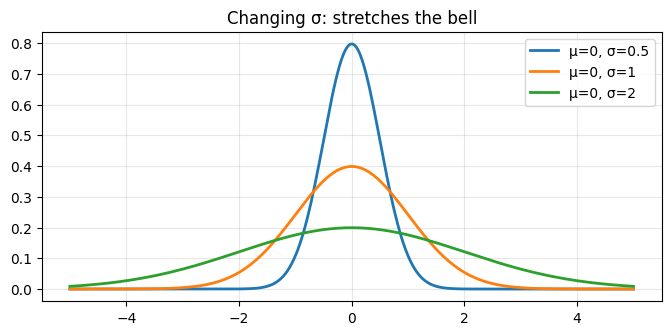

In [6]:
# Three Gaussians with the SAME mean but different widths
plt.figure(figsize=(8, 3.5))
for sigma_, color in zip([0.5, 1, 2], ["C0", "C1", "C2"]):
    plt.plot(x, gauss_pdf(x, 0, sigma_), color=color, linewidth=2, label=f"μ=0, σ={sigma_}")
plt.title("Changing σ: stretches the bell")
plt.legend(); plt.grid(alpha=0.3); plt.show()


## 4. Variance vs. standard deviation

These are two names for almost the same thing:

- **Standard deviation σ** — measured in the same units as the data (e.g. €).
- **Variance σ²** — just σ squared. Has weird squared units (e.g. €²) but is mathematically convenient.

**numpy uses σ (the std), not the variance**, as the parameter of `rng.normal`. Don't mix them up.


In [7]:
sigma_ = 15000          # standard deviation (€)
variance = sigma_ ** 2  # variance (€²)
print(f"std      = {sigma_}")
print(f"variance = {variance}")
print(f"sqrt(variance) = {np.sqrt(variance):.0f}  ← gives you back the std")


std      = 15000
variance = 225000000
sqrt(variance) = 15000  ← gives you back the std


## 5. The 68-95-99.7 rule

For any Gaussian:

- About **68%** of samples lie within **±1σ** of the mean.
- About **95%** within **±2σ**.
- About **99.7%** within **±3σ**.

That's why σ is so useful: it tells you the *typical* size of variations.


In [8]:
# Verify the rule on a real sample
sample = rng.normal(0, 1, size=100_000)

for k in [1, 2, 3]:
    inside = np.mean(np.abs(sample) <= k)
    print(f"Within ±{k}σ: {inside*100:.2f}%  (theory: {[68.27, 95.45, 99.73][k-1]}%)")


Within ±1σ: 68.15%  (theory: 68.27%)
Within ±2σ: 95.36%  (theory: 95.45%)
Within ±3σ: 99.70%  (theory: 99.73%)


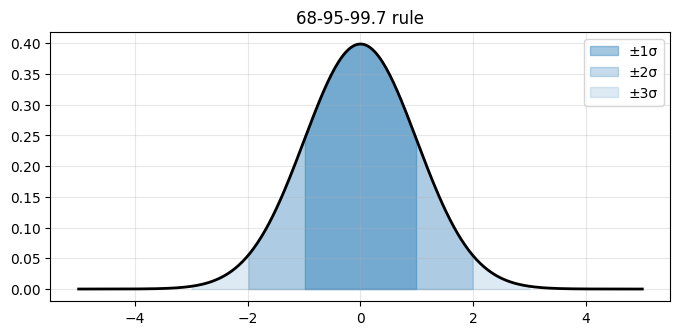

In [9]:
# Visualise the rule
plt.figure(figsize=(8, 3.5))
plt.plot(x, gauss_pdf(x, 0, 1), color="black", linewidth=2)
for k, alpha in zip([1, 2, 3], [0.4, 0.25, 0.15]):
    region = x[(x >= -k) & (x <= k)]
    plt.fill_between(region, gauss_pdf(region, 0, 1), alpha=alpha, color="C0",
                     label=f"±{k}σ")
plt.title("68-95-99.7 rule")
plt.legend(); plt.grid(alpha=0.3); plt.show()


## 6. Other useful random generators

Not everything is Gaussian. Three more you'll use in your thesis:

- `rng.uniform(low, high, size)` — every value between *low* and *high* equally likely.
- `rng.integers(low, high, size)` — random whole numbers (e.g. random class labels).
- `rng.choice(options, size)` — pick from a list of options (e.g. random categorical values).


In [10]:
rng = np.random.default_rng(seed=0)

print("Uniform between 0 and 1:    ", rng.uniform(0, 1, size=5).round(3))
print("Integers between 0 and 10:  ", rng.integers(0, 10, size=5))
print("Choice from ['A','B','C']:  ", rng.choice(["A", "B", "C"], size=5))


Uniform between 0 and 1:     [0.637 0.27  0.041 0.017 0.813]
Integers between 0 and 10:   [6 9 5 6 9]
Choice from ['A','B','C']:   ['C' 'B' 'B' 'B' 'C']


## 7. The thesis use case — Gaussian noise augmentation

Now the part that matters for your benchmark.

One of the augmentations you'll implement is **Gaussian noise**: add a small random wiggle to each feature value, so that the encoder learns to ignore small noise.

$$ x_{\text{aug}} = x + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, \sigma^2) $$

The hyperparameter is **σ** — the noise strength. Small σ = barely changes the data. Larger σ = stronger perturbation.


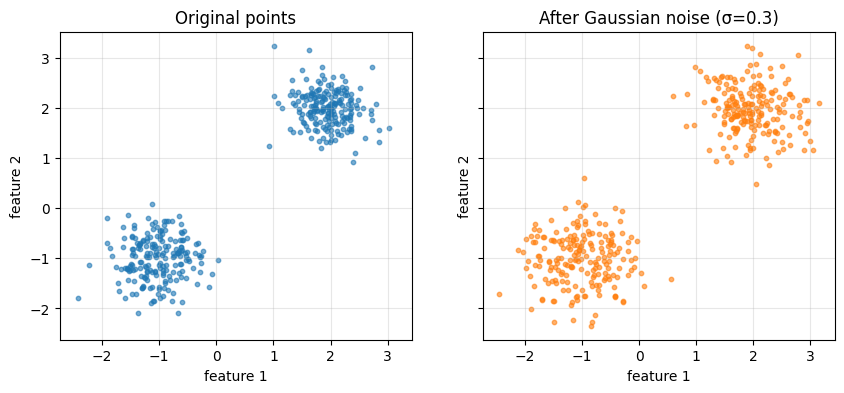

In [11]:
# Simulate: 200 data points in 2D, then add Gaussian noise
rng = np.random.default_rng(seed=1)

# Original points (two clusters, for illustration)
n = 200
X = np.vstack([
    rng.normal(loc=[ 2,  2], scale=0.4, size=(n, 2)),
    rng.normal(loc=[-1, -1], scale=0.4, size=(n, 2)),
])

# Add Gaussian noise — the augmentation
sigma_noise = 0.3
noise = rng.normal(0, sigma_noise, size=X.shape)
X_aug = X + noise

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
axes[0].scatter(X[:, 0], X[:, 1], s=10, alpha=0.6, color="C0")
axes[0].set_title("Original points")
axes[1].scatter(X_aug[:, 0], X_aug[:, 1], s=10, alpha=0.6, color="C1")
axes[1].set_title(f"After Gaussian noise (σ={sigma_noise})")
for ax in axes:
    ax.grid(alpha=0.3); ax.set_xlabel("feature 1"); ax.set_ylabel("feature 2")
plt.show()


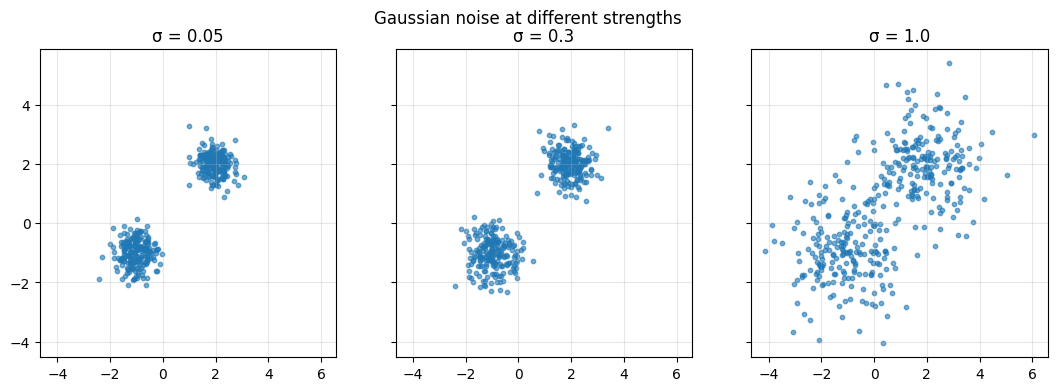

In [12]:
# What if you change sigma? Try σ = 0.05, 0.3, 1.0
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=True, sharey=True)
for ax, s in zip(axes, [0.05, 0.3, 1.0]):
    noise = rng.normal(0, s, size=X.shape)
    Xa = X + noise
    ax.scatter(Xa[:, 0], Xa[:, 1], s=10, alpha=0.6)
    ax.set_title(f"σ = {s}"); ax.grid(alpha=0.3)
plt.suptitle("Gaussian noise at different strengths")
plt.show()


**That's the intuition for choosing σ in your thesis:**

- Too small (σ ≈ 0.01) — the augmented view is almost identical to the original, the model learns nothing new.
- Too large (σ ≈ 1.0) — the augmented view destroys the structure, the model can't tell what's a positive pair.
- The sweet spot is **moderate noise** that preserves the structure but forces the encoder to be robust.

Finding that sweet spot is exactly what your sensitivity studies in week 7 will explore.


## 8. Reproducibility — why seeds matter

Every random function takes a `rng` (random generator). When you create the generator with `np.random.default_rng(seed=...)`, the same seed always gives the same sequence of numbers.

For your thesis this is **non-negotiable**: every experiment must be reproducible. Always set a seed.


In [13]:
# Same seed → same numbers
print("Run 1:", np.random.default_rng(seed=42).normal(0, 1, size=4).round(3))
print("Run 2:", np.random.default_rng(seed=42).normal(0, 1, size=4).round(3))

# Different seed → different numbers
print("Seed 7:", np.random.default_rng(seed=7).normal(0, 1, size=4).round(3))


Run 1: [ 0.305 -1.04   0.75   0.941]
Run 2: [ 0.305 -1.04   0.75   0.941]
Seed 7: [ 0.001  0.299 -0.274 -0.891]


**Recommended pattern for your thesis pipeline:**

```python
SEED = 42
rng  = np.random.default_rng(SEED)
import torch
torch.manual_seed(SEED)
```

Put this in your configuration cell at the top of every notebook and every benchmark script. Then your results are reproducible across runs.


## Quick recap

- Gaussian = bell curve. Two numbers describe it: μ (centre), σ (width).
- Variance σ² = σ squared. numpy takes σ, not σ².
- 68-95-99.7 rule: ±1σ, ±2σ, ±3σ contain those fractions of samples.
- `rng = np.random.default_rng(seed); rng.normal(mu, sigma, size)` — that's the whole API.
- **Gaussian noise augmentation:** `X_aug = X + rng.normal(0, sigma, size=X.shape)` — your thesis will tune σ to find the sweet spot.
- Always seed your generators — reproducibility is part of a good benchmark.
